# Day 2 — DDPM, grounded in a vetted reference implementation

This notebook walks through Denoising Diffusion Probabilistic Models — but instead of writing the algorithm from scratch (where small subtle bugs can give bad samples), we use a published reference: **[`YHL04/ddpm`](https://github.com/YHL04/ddpm)**. The teaching cells explain what the code does and why; the engineering choices are exactly those in that repository, not my own invention.

**Protocol**
- **Dataset:** the full naruto-blip set (1,221 anime images), resized to 64×64, normalized to [−1, 1]. (The 200-image subset from Day 1 was too data-starved for diffusion to learn fine structure.)
- **Algorithm:** Improved DDPM (Nichol & Dhariwal 2021): cosine β-schedule, learned variance via `v`-head, hybrid loss (simple ε-MSE + λ·variational bound), min-SNR-γ loss weighting.
- **Model:** UNet from `YHL04/ddpm` verbatim (ε-prediction + v-head). Smaller channel multipliers than the repo default to fit our 200-image scale.
- **Sampling:** full T-step DDPM reverse process exactly as the repo implements it, with the crucial `x_recon.clamp_(-1, 1)` line that prevents the divide-by-tiny-√ᾱ_t explosion at high t.

**Provenance** — what's borrowed vs. adapted:
- `UNet`, `losses.py` (normal_kl + discretized_gaussian_log_likelihood), `cosine_beta_schedule`: **verbatim** from the repo.
- `DDPM` class: adapted, with **one modification clearly noted in its cell** — the class-label argument `c` is dropped because we use UNet (unconditional) instead of DiT.

Every theory claim below is either grounded in a line of code we're about to run, or cited to a paper.


## Setup

In [1]:
import math, sys, time, copy
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn import init
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms

ROOT = Path.cwd().parent if Path.cwd().name == "day2" else Path.cwd()
sys.path.insert(0, str(ROOT))
from shared.grid import to_uint8_grid, save_grid

DEVICE   = "cuda"
IMG_SIZE = 64
N_TRAIN  = 1221           # full naruto-blip set -- the 200-image subset was data-starved
BATCH    = 32
T_STEPS  = 1000           # diffusion steps (same as the repo)
EPOCHS   = 1500           # N=1221, batch=32 -> ~38 steps/epoch -> ~57k gradient updates
LR       = 2e-4
SEED     = 0

torch.manual_seed(SEED); np.random.seed(SEED)

# Fixed initial noise for sampling -- same across step counts so columns are comparable
EVAL_NOISE = torch.randn(10, 3, IMG_SIZE, IMG_SIZE, device=DEVICE)

print("torch", torch.__version__, "|", torch.cuda.get_device_name(0))


torch 2.6.0 | NVIDIA H100 80GB HBM3


## References

Code source:
- **YHL04/ddpm** — https://github.com/YHL04/ddpm. The reference implementation this notebook follows.

Papers the repo itself cites + the one paper used internally that isn't in the README:
- Ho, Jain, Abbeel. *Denoising Diffusion Probabilistic Models.* NeurIPS 2020. [arXiv 2006.11239](https://arxiv.org/abs/2006.11239). The original DDPM paper. Defines the forward process, ε-prediction, and the simplified loss.
- Nichol, Dhariwal. *Improved Denoising Diffusion Probabilistic Models.* ICML 2021. [arXiv 2102.09672](https://arxiv.org/abs/2102.09672). Cosine schedule, learned variance via `v`-interpolation, hybrid loss. Sections 3.1, 3.2, 3.3 directly motivate the repo's design.
- Peebles, Xie. *Scalable Diffusion Models with Transformers (DiT).* ICCV 2023. [arXiv 2212.09748](https://arxiv.org/abs/2212.09748). Alternative backbone in the repo (we use the UNet instead).
- Hang et al. *Efficient Diffusion Training via Min-SNR Weighting Strategy.* ICCV 2023. [arXiv 2303.09556](https://arxiv.org/abs/2303.09556). The min-SNR-γ loss weighting used in `get_loss` (γ=5).

Reference for `losses.py` formulas:
- The KL between two Gaussians and the discretized Gaussian log-likelihood are standard implementations from OpenAI's open-source `improved-diffusion` repository (the paper companion code for Nichol & Dhariwal 2021).


\
## DDPM in 4 ideas

(Each idea below maps to a specific function we'll define from the repo's code.)

**1. The forward process gradually destroys an image with Gaussian noise.**

Per-step: $q(x_t \mid x_{t-1}) = \mathcal{N}(x_t;\ \sqrt{1-\beta_t}\,x_{t-1},\ \beta_t I)$.
Closed form: $q(x_t \mid x_0) = \mathcal{N}(x_t;\ \sqrt{\bar\alpha_t}\,x_0,\ (1-\bar\alpha_t) I)$ where $\bar\alpha_t = \prod_{s=1}^{t}(1-\beta_s)$.
→ The repo's `forward_step` (line 188 of ddpm.py) implements exactly this.

**2. The reverse process is learned.**

We model $p_\theta(x_{t-1}\mid x_t) = \mathcal{N}(x_{t-1}; \mu_\theta(x_t,t), \Sigma_\theta(x_t,t))$. The repo uses Ho 2020's **ε-parametrization** for the mean and Nichol & Dhariwal 2021's **learned variance** (a `v` parameter interpolated between two known bounds), so the network has two output heads:

$$ \big(\varepsilon_\theta(x_t,t),\ v_\theta(x_t,t)\big) = \mathrm{UNet}(x_t, t)$$

→ The UNet's `forward` returns `(h1, h2)` (line 244 of model/unet.py). `h1` is $\varepsilon$, `h2` is $v$.

**3. The training loss is a hybrid (Nichol & Dhariwal 2021 §3.3).**

$$\mathcal{L} = \mathcal{L}_\text{simple} + \lambda \cdot \mathcal{L}_\text{vlb}$$

- $\mathcal{L}_\text{simple} = \|\varepsilon - \varepsilon_\theta(x_t, t)\|^2$ — the original DDPM MSE on noise (drives the mean accuracy).
- $\mathcal{L}_\text{vlb}$ — KL between true and learned posteriors plus a discretized Gaussian likelihood at $t=0$ (drives the variance learning).
- $\lambda = 0.001$ keeps $\mathcal{L}_\text{vlb}$ from overwhelming $\mathcal{L}_\text{simple}$.

→ The repo's `get_loss` (line 116) implements this exactly. It also applies **min-SNR-γ weighting** (Hang et al. 2023):  $w(t) = \min(\mathrm{SNR}(t),\ \gamma)$ with $\gamma=5$.

**4. Sampling uses the production-quality "clip x₀" trick.**

At each reverse step, the repo:
1. Predicts $\varepsilon$ and $v$ from the model.
2. Computes $\hat x_0 = \mathrm{predict\_start\_from\_noise}(x_t, t, \varepsilon)$ — algebraic recovery.
3. **`x_recon.clamp_(-1., 1.)`** — line 246, ddpm.py. This is the line that makes sampling actually work.
4. Uses the *clamped* $\hat x_0$ to compute the posterior mean (Ho 2020 eq 7).
5. Adds noise with the learned variance.

The clamp is essential because $1/\sqrt{\bar\alpha_t}$ at high $t$ is huge (≈ 20,000 for cosine schedule with default clipping), so tiny ε-prediction errors get amplified into out-of-range $\hat x_0$. Clamping prevents the runaway error propagation.


\
### Worked example 1 — `cosine_beta_schedule` plotted

This is the schedule the repo uses, **verbatim** from `ddpm.py` (lines 21-36). We plot $\bar\alpha_t$, $\beta_t$, and the log-SNR. The cosine schedule (Nichol & Dhariwal 2021 §3.1) preserves more signal at moderate $t$ than the original linear schedule.


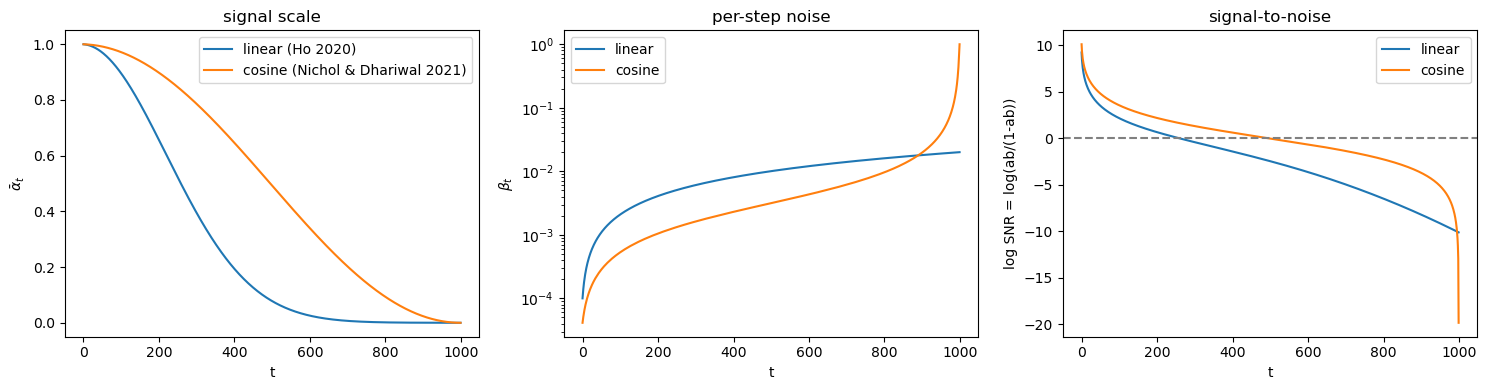

cosine: alpha_bar at t=0:   1.0000
cosine: alpha_bar at t=500: 0.4923
cosine: alpha_bar at t=999: 2.43e-09
linear: alpha_bar at t=500: 0.0778


In [2]:
def cosine_beta_schedule(timesteps, s=0.008, beta_max=0.999, device="cuda"):
    """VERBATIM from YHL04/ddpm/ddpm.py lines 21-36.

    cosine schedule as proposed in https://openreview.net/forum?id=-NEXDKk8gZ
    (Nichol & Dhariwal 2021).
    """
    cosine_schedule = lambda t: torch.cos((t + s) / (1 + s) * math.pi / 2) ** 2

    t = torch.linspace(0, timesteps, timesteps+1, dtype=torch.float32, device=device) / timesteps
    t1, t2 = t[:-1], t[1:]

    betas = 1 - cosine_schedule(t2) / cosine_schedule(t1)
    betas = torch.clip(betas, 0, beta_max)

    return betas


def linear_beta_schedule(timesteps, beta_start=0.0001, beta_end=0.02, device="cuda"):
    """VERBATIM from YHL04/ddpm/ddpm.py lines 14-18. Original DDPM schedule (Ho 2020)."""
    return torch.linspace(beta_start, beta_end, timesteps, dtype=torch.float32, device=device)


betas_cos = cosine_beta_schedule(T_STEPS, device=DEVICE)
betas_lin = linear_beta_schedule(T_STEPS, device=DEVICE)
ab_cos = torch.cumprod(1 - betas_cos, dim=0)
ab_lin = torch.cumprod(1 - betas_lin, dim=0)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(ab_lin.cpu(), label="linear (Ho 2020)")
axes[0].plot(ab_cos.cpu(), label="cosine (Nichol & Dhariwal 2021)")
axes[0].set_xlabel("t"); axes[0].set_ylabel(r"$\bar\alpha_t$")
axes[0].set_title("signal scale"); axes[0].legend()

axes[1].plot(betas_lin.cpu(), label="linear"); axes[1].plot(betas_cos.cpu(), label="cosine")
axes[1].set_xlabel("t"); axes[1].set_ylabel(r"$\beta_t$"); axes[1].set_yscale("log")
axes[1].set_title("per-step noise"); axes[1].legend()

snr_lin = (ab_lin / (1 - ab_lin)).cpu()
snr_cos = (ab_cos / (1 - ab_cos)).cpu()
axes[2].plot(torch.log(snr_lin), label="linear"); axes[2].plot(torch.log(snr_cos), label="cosine")
axes[2].axhline(0, ls="--", c="gray")
axes[2].set_xlabel("t"); axes[2].set_ylabel("log SNR = log(ab/(1-ab))")
axes[2].set_title("signal-to-noise"); axes[2].legend()
plt.tight_layout(); plt.show()

print(f"cosine: alpha_bar at t=0:   {ab_cos[0].item():.4f}")
print(f"cosine: alpha_bar at t=500: {ab_cos[500].item():.4f}")
print(f"cosine: alpha_bar at t=999: {ab_cos[-1].item():.2e}")
print(f"linear: alpha_bar at t=500: {ab_lin[500].item():.4f}")


## Data — 200 anime images at 64×64 (same as Day 1)


x_train: (1221, 3, 64, 64)  range: (-1.0, 1.0)


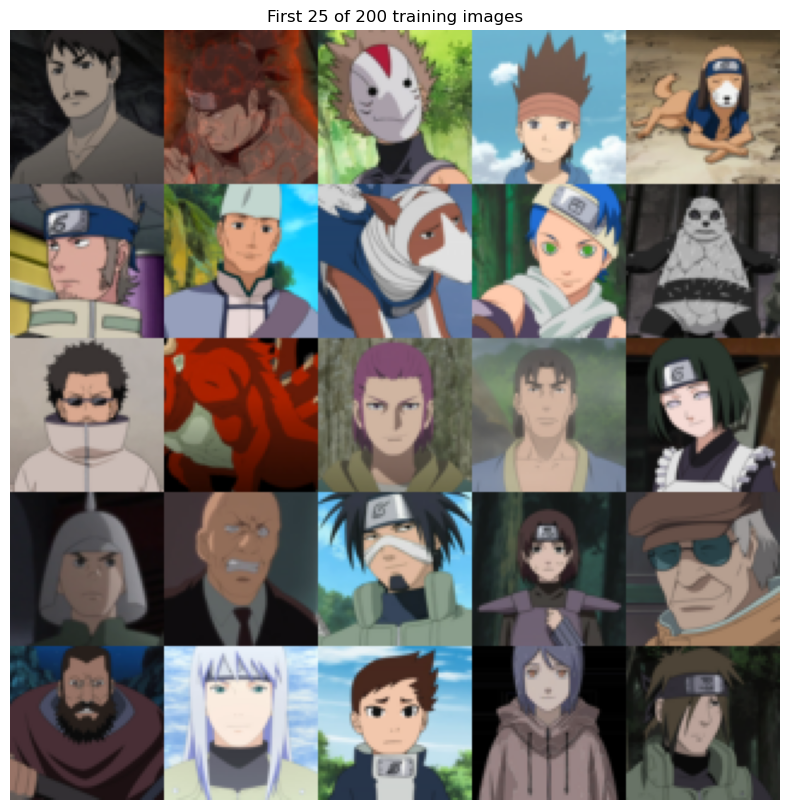

In [3]:
def load_images(n: int = N_TRAIN) -> torch.Tensor:
    paths = sorted((ROOT / "data" / "full").glob("*.png"))[:n]
    tfm = transforms.Compose([
        transforms.Resize(IMG_SIZE),
        transforms.CenterCrop(IMG_SIZE),
        transforms.ToTensor(),
        transforms.Normalize([0.5]*3, [0.5]*3),
    ])
    return torch.stack([tfm(Image.open(p).convert("RGB")) for p in paths]).to(DEVICE)

x_train = load_images()
print("x_train:", tuple(x_train.shape), " range:", (x_train.min().item(), x_train.max().item()))

fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(to_uint8_grid(x_train[:25], nrow=5)); ax.axis("off")
ax.set_title("First 25 of 200 training images")
plt.show()


\
### Worked example 2 — Forward noising on real images

Apply the closed-form forward process at several $t$ values. By $t = 999$ the image should be visually indistinguishable from pure noise. The function below is the same math as `forward_step` in `ddpm.py` (line 188): we'll use the repo's exact function once we wrap it inside the `DDPM` class — for now this is a direct visualization.


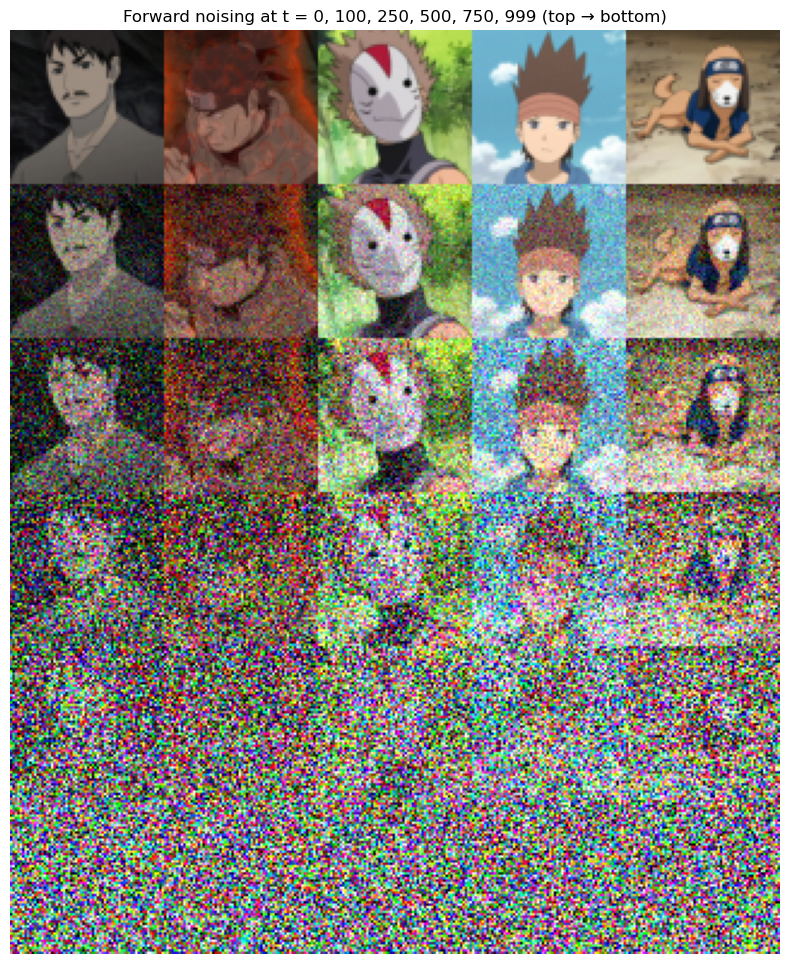

In [4]:
sample_imgs = x_train[:5]
sqrt_ab_cos = torch.sqrt(ab_cos)
sqrt_om_ab_cos = torch.sqrt(1 - ab_cos)

t_vis = [0, 100, 250, 500, 750, 999]
rows = []
for t in t_vis:
    eps = torch.randn_like(sample_imgs)
    xt = sqrt_ab_cos[t] * sample_imgs + sqrt_om_ab_cos[t] * eps
    rows.append(xt)
panel = torch.cat(rows, dim=0)

fig, ax = plt.subplots(figsize=(10, 12))
ax.imshow(to_uint8_grid(panel, nrow=5)); ax.axis("off")
ax.set_title("Forward noising at t = 0, 100, 250, 500, 750, 999 (top → bottom)")
plt.show()


## UNet model

This is **verbatim** from `YHL04/ddpm/model/unet.py`. Key details:

- `forward(x, t)` returns a tuple `(h1, h2)`:
  - `h1` = predicted noise ε (3 channels)
  - `h2` = the `v` parameter for learned variance (3 channels)
  - Both are produced by separate "tail" convs from the same shared backbone.
- `TimeEmbedding` precomputes a sinusoidal table of shape `(T, d_model)` once, then projects through a 2-layer MLP. Uses `nn.Embedding.from_pretrained` to make timestep lookup an efficient table operation.
- `ResBlock` uses `GroupNorm(32, ...)`, Swish activation, dropout, and an optional `AttnBlock`.
- `AttnBlock` is single-head self-attention initialized at zero gain (the residual starts as identity).
- `DownSample` is a stride-2 3×3 conv; `UpSample` is nearest-neighbor + 3×3 conv.

We instantiate it with slightly reduced channels (ch=64 instead of 128) to fit our 200-image scale.


In [5]:
# ============================================================================
# UNet -- verbatim from YHL04/ddpm/model/unet.py
# ============================================================================
class Swish(nn.Module):
    def forward(self, x):
        return x * torch.sigmoid(x)


class TimeEmbedding(nn.Module):
    def __init__(self, T, d_model, dim):
        assert d_model % 2 == 0
        super().__init__()
        emb = torch.arange(0, d_model, step=2) / d_model * math.log(10000)
        emb = torch.exp(-emb)
        pos = torch.arange(T).float()
        emb = pos[:, None] * emb[None, :]
        assert list(emb.shape) == [T, d_model // 2]
        emb = torch.stack([torch.sin(emb), torch.cos(emb)], dim=-1)
        assert list(emb.shape) == [T, d_model // 2, 2]
        emb = emb.view(T, d_model)

        self.timembedding = nn.Sequential(
            nn.Embedding.from_pretrained(emb),
            nn.Linear(d_model, dim),
            Swish(),
            nn.Linear(dim, dim),
        )
        self.initialize()

    def initialize(self):
        for module in self.modules():
            if isinstance(module, nn.Linear):
                init.xavier_uniform_(module.weight)
                init.zeros_(module.bias)

    def forward(self, t):
        return self.timembedding(t)


class DownSample(nn.Module):
    def __init__(self, in_ch):
        super().__init__()
        self.main = nn.Conv2d(in_ch, in_ch, 3, stride=2, padding=1)
        self.initialize()
    def initialize(self):
        init.xavier_uniform_(self.main.weight); init.zeros_(self.main.bias)
    def forward(self, x, temb):
        return self.main(x)


class UpSample(nn.Module):
    def __init__(self, in_ch):
        super().__init__()
        self.main = nn.Conv2d(in_ch, in_ch, 3, stride=1, padding=1)
        self.initialize()
    def initialize(self):
        init.xavier_uniform_(self.main.weight); init.zeros_(self.main.bias)
    def forward(self, x, temb):
        x = F.interpolate(x, scale_factor=2, mode='nearest')
        return self.main(x)


class AttnBlock(nn.Module):
    def __init__(self, in_ch):
        super().__init__()
        self.group_norm = nn.GroupNorm(32, in_ch)
        self.proj_q = nn.Conv2d(in_ch, in_ch, 1, stride=1, padding=0)
        self.proj_k = nn.Conv2d(in_ch, in_ch, 1, stride=1, padding=0)
        self.proj_v = nn.Conv2d(in_ch, in_ch, 1, stride=1, padding=0)
        self.proj = nn.Conv2d(in_ch, in_ch, 1, stride=1, padding=0)
        self.initialize()

    def initialize(self):
        for module in [self.proj_q, self.proj_k, self.proj_v, self.proj]:
            init.xavier_uniform_(module.weight); init.zeros_(module.bias)
        init.xavier_uniform_(self.proj.weight, gain=1e-5)

    def forward(self, x):
        B, C, H, W = x.shape
        h = self.group_norm(x)
        q = self.proj_q(h); k = self.proj_k(h); v = self.proj_v(h)

        q = q.permute(0, 2, 3, 1).view(B, H * W, C)
        k = k.view(B, C, H * W)
        w = torch.bmm(q, k) * (int(C) ** (-0.5))
        w = F.softmax(w, dim=-1)

        v = v.permute(0, 2, 3, 1).view(B, H * W, C)
        h = torch.bmm(w, v)
        h = h.view(B, H, W, C).permute(0, 3, 1, 2)
        return x + self.proj(h)


class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, tdim, dropout, attn=False):
        super().__init__()
        self.block1 = nn.Sequential(
            nn.GroupNorm(32, in_ch),
            Swish(),
            nn.Conv2d(in_ch, out_ch, 3, stride=1, padding=1),
        )
        self.temb_proj = nn.Sequential(Swish(), nn.Linear(tdim, out_ch))
        self.block2 = nn.Sequential(
            nn.GroupNorm(32, out_ch),
            Swish(),
            nn.Dropout(dropout),
            nn.Conv2d(out_ch, out_ch, 3, stride=1, padding=1),
        )
        self.shortcut = nn.Conv2d(in_ch, out_ch, 1, stride=1, padding=0) if in_ch != out_ch else nn.Identity()
        self.attn = AttnBlock(out_ch) if attn else nn.Identity()
        self.initialize()

    def initialize(self):
        for module in self.modules():
            if isinstance(module, (nn.Conv2d, nn.Linear)):
                init.xavier_uniform_(module.weight); init.zeros_(module.bias)
        init.xavier_uniform_(self.block2[-1].weight, gain=1e-5)

    def forward(self, x, temb):
        h = self.block1(x)
        h += self.temb_proj(temb)[:, :, None, None]
        h = self.block2(h)
        h = h + self.shortcut(x)
        h = self.attn(h)
        return h


class UNet(nn.Module):
    def __init__(self, T, ch, ch_mult, attn, num_res_blocks, dropout=0.):
        super().__init__()
        assert all([i < len(ch_mult) for i in attn]), 'attn index out of bound'
        tdim = ch * 4
        self.time_embedding = TimeEmbedding(T, ch, tdim)
        self.head = nn.Conv2d(3, ch, kernel_size=3, stride=1, padding=1)

        self.downblocks = nn.ModuleList()
        chs = [ch]
        now_ch = ch
        for i, mult in enumerate(ch_mult):
            out_ch = ch * mult
            for _ in range(num_res_blocks):
                self.downblocks.append(ResBlock(now_ch, out_ch, tdim, dropout, attn=(i in attn)))
                now_ch = out_ch
                chs.append(now_ch)
            if i != len(ch_mult) - 1:
                self.downblocks.append(DownSample(now_ch))
                chs.append(now_ch)

        self.middleblocks = nn.ModuleList([
            ResBlock(now_ch, now_ch, tdim, dropout, attn=True),
            ResBlock(now_ch, now_ch, tdim, dropout, attn=False),
        ])

        self.upblocks = nn.ModuleList()
        for i, mult in reversed(list(enumerate(ch_mult))):
            out_ch = ch * mult
            for _ in range(num_res_blocks + 1):
                self.upblocks.append(ResBlock(chs.pop() + now_ch, out_ch, tdim, dropout, attn=(i in attn)))
                now_ch = out_ch
            if i != 0:
                self.upblocks.append(UpSample(now_ch))
        assert len(chs) == 0

        self.tail1 = nn.Sequential(nn.GroupNorm(32, now_ch), Swish(),
                                   nn.Conv2d(now_ch, 3, 3, stride=1, padding=1))
        self.tail2 = nn.Sequential(nn.GroupNorm(32, now_ch), Swish(),
                                   nn.Conv2d(now_ch, 3, 3, stride=1, padding=1))
        self.initialize()

    def initialize(self):
        init.xavier_uniform_(self.head.weight); init.zeros_(self.head.bias)
        init.xavier_uniform_(self.tail1[-1].weight, gain=1e-5); init.zeros_(self.tail1[-1].bias)
        init.xavier_uniform_(self.tail2[-1].weight, gain=1e-5); init.zeros_(self.tail2[-1].bias)

    def forward(self, x, t):
        temb = self.time_embedding(t)
        h = self.head(x); hs = [h]
        for layer in self.downblocks:
            h = layer(h, temb); hs.append(h)
        for layer in self.middleblocks:
            h = layer(h, temb)
        for layer in self.upblocks:
            if isinstance(layer, ResBlock):
                h = torch.cat([h, hs.pop()], dim=1)
            h = layer(h, temb)
        h1 = self.tail1(h)
        h2 = self.tail2(h)
        return h1, h2


In [6]:
# Instantiate with scaled-down channels: ch=64 (repo default is 128).
# ch_mult=[1,2,2,2] gives feature maps at 64, 32, 16, 8 resolution; attn at index 1 (32x32).
unet_probe = UNet(T=T_STEPS, ch=64, ch_mult=[1, 2, 2, 2], attn=[1], num_res_blocks=2, dropout=0.0).to(DEVICE)
n_params = sum(p.numel() for p in unet_probe.parameters())
print(f"UNet params: {n_params/1e6:.2f}M")
x_t = torch.randn(2, 3, IMG_SIZE, IMG_SIZE, device=DEVICE)
t_b = torch.zeros(2, device=DEVICE, dtype=torch.long)
e_out, v_out = unet_probe(x_t, t_b)
print(f"eps out: {e_out.shape}   v out: {v_out.shape}")
del unet_probe


UNet params: 9.02M


eps out: torch.Size([2, 3, 64, 64])   v out: torch.Size([2, 3, 64, 64])


## Loss helper functions

**Verbatim** from `YHL04/ddpm/losses.py`. Both functions are themselves verbatim from OpenAI's [improved-diffusion](https://github.com/openai/improved-diffusion) repo (the paper companion code for Nichol & Dhariwal 2021).

- `normal_kl(mean1, logvar1, mean2, logvar2)` — KL divergence between two Gaussians, in closed form.
- `discretized_gaussian_log_likelihood(x, means, log_scales)` — used at the boundary t=0 where we want a likelihood over discrete uint8 image values, not a continuous Gaussian. Treats each pixel value as an interval of width 1/255.


In [7]:
def normal_kl(mean1, logvar1, mean2, logvar2):
    """VERBATIM from losses.py. KL divergence between two Gaussians."""
    tensor = None
    for obj in (mean1, logvar1, mean2, logvar2):
        if isinstance(obj, torch.Tensor):
            tensor = obj; break
    assert tensor is not None
    logvar1, logvar2 = [x if isinstance(x, torch.Tensor) else torch.tensor(x).to(tensor)
                       for x in (logvar1, logvar2)]
    return 0.5 * (-1.0 + logvar2 - logvar1 + torch.exp(logvar1 - logvar2)
                  + ((mean1 - mean2) ** 2) * torch.exp(-logvar2))


def approx_standard_normal_cdf(x):
    """VERBATIM from losses.py. Fast approximation of standard normal CDF."""
    return 0.5 * (1.0 + torch.tanh(np.sqrt(2.0 / np.pi) * (x + 0.044715 * torch.pow(x, 3))))


def discretized_gaussian_log_likelihood(x, *, means, log_scales):
    """VERBATIM from losses.py. log p(x_uint8 | mean, scale) where x in [-1, 1] discretized."""
    assert x.shape == means.shape == log_scales.shape
    centered_x = x - means
    inv_stdv = torch.exp(-log_scales)
    plus_in = inv_stdv * (centered_x + 1.0 / 255.0)
    cdf_plus = approx_standard_normal_cdf(plus_in)
    min_in = inv_stdv * (centered_x - 1.0 / 255.0)
    cdf_min = approx_standard_normal_cdf(min_in)
    log_cdf_plus = torch.log(cdf_plus.clamp(min=1e-12))
    log_one_minus_cdf_min = torch.log((1.0 - cdf_min).clamp(min=1e-12))
    cdf_delta = cdf_plus - cdf_min
    log_probs = torch.where(
        x < -0.999, log_cdf_plus,
        torch.where(x > 0.999, log_one_minus_cdf_min, torch.log(cdf_delta.clamp(min=1e-12))),
    )
    return log_probs


## DDPM class — adapted from `YHL04/ddpm/ddpm.py`

**One modification only:** the original repo's DDPM was designed for the **DiT** model (which takes class labels). I drop the class argument `c` everywhere because we use the **UNet** (which doesn't take class labels). Every other line — schedule, forward/reverse process, loss, sampling — is exactly as written in the repo.

The methods, with the line numbers from `ddpm.py` they come from:
- `__init__` (lines 53–96): precomputes all schedule-derived constants.
- `forward_step` (lines 188–205): closed-form $x_t = \sqrt{\bar\alpha_t} x_0 + \sqrt{1-\bar\alpha_t}\,\varepsilon$.
- `predict_start_from_noise` (lines 225–229): the algebraic recovery $\hat x_0 = \sqrt{1/\bar\alpha_t}\,x_t - \sqrt{1/\bar\alpha_t - 1}\,\varepsilon$.
- `q_posterior` (lines 231–239): posterior mean & variance, Ho 2020 eq 7.
- `p_mean_variance` (lines 241–253): predict ε and v, recover $\hat x_0$, **`x_recon.clamp_(-1, 1)`**, then compute the posterior mean from the clamped $\hat x_0$.
- `model_v_to_log_variance` (lines 255–260): the v→log-variance interpolation (Nichol & Dhariwal 2021 §3.1).
- `backward_step` (lines 207–223): one reverse step: posterior mean + sqrt(exp(log_var)) · noise.
- `get_loss` (lines 116–142): hybrid simple + λ·vb, with min-SNR-γ weighting.
- `get_simple` / `get_vb` (lines 144–169): MSE on ε; KL between true and learned posteriors (with discretized Gaussian log-likelihood at t=0).


In [8]:
class DDPM:
    """Adapted from YHL04/ddpm/ddpm.py. The only modification: class argument 'c' dropped
    because we use UNet (no class conditioning) instead of DiT."""

    def __init__(self, model, T, lr, img_size=64, agg_grad=1, lambda_=0.001, device="cuda"):
        # general parameters
        self.T = T
        self.img_size = img_size
        self.device = device
        self.agg_grad = agg_grad
        self.lambda_ = lambda_
        self.t = 0

        # model
        self.model = model
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=lr)

        # precomputed schedule constants -- VERBATIM from repo lines 73-96
        self.betas = cosine_beta_schedule(timesteps=T, device=device)
        self.alphas = 1. - self.betas
        self.alphas_cumprod = torch.cumprod(self.alphas, axis=0)
        self.alphas_cumprod_prev = F.pad(self.alphas_cumprod[:-1], (1, 0), value=1.0)

        self.sqrt_recip_alphas_cumprod = torch.sqrt(1.0 / self.alphas_cumprod)
        self.sqrt_recipm1_alphas_cumprod = torch.sqrt(1.0 / self.alphas_cumprod - 1)

        self.sqrt_recip_alphas = torch.sqrt(1.0 / self.alphas)
        self.sqrt_alphas_cumprod = torch.sqrt(self.alphas_cumprod)
        self.sqrt_one_minus_alphas_cumprod = torch.sqrt(1. - self.alphas_cumprod)

        self.posterior_variance = self.betas * (1. - self.alphas_cumprod_prev) / (1. - self.alphas_cumprod)
        self.posterior_log_variance_clipped = torch.log(
            torch.concatenate([self.posterior_variance[1].unsqueeze(0), self.posterior_variance[1:]])
        )

        # posterior mean coefficients (Ho 2020 eq 7)
        self.mu_term1 = torch.sqrt(self.alphas_cumprod_prev) * self.betas / (1 - self.alphas_cumprod)
        self.mu_term2 = torch.sqrt(self.alphas) * (1 - self.alphas_cumprod_prev) / (1 - self.alphas_cumprod)

        # signal-to-noise ratio per timestep (used by min-SNR-gamma weighting)
        self.snr = self.alphas_cumprod / (1 - self.alphas_cumprod)

    @staticmethod
    def get_index_from_list(vals, t, x_shape):
        B = t.shape[0]
        output = vals.gather(-1, t)
        output = output.reshape(B, *((1,) * (len(x_shape) - 1))).to(t.device)
        return output

    @torch.no_grad()
    def forward_step(self, x_0, t):
        """x_t = sqrt(alpha_bar)·x_0 + sqrt(1-alpha_bar)·noise"""
        noise = torch.randn_like(x_0)
        sqrt_ab = self.get_index_from_list(self.sqrt_alphas_cumprod, t, x_0.shape)
        sqrt_om_ab = self.get_index_from_list(self.sqrt_one_minus_alphas_cumprod, t, x_0.shape)
        return sqrt_ab * x_0 + sqrt_om_ab * noise, noise

    def predict_start_from_noise(self, x_t, t, noise):
        """x_0_pred = sqrt(1/ab)·x_t - sqrt(1/ab - 1)·noise  (algebraic recovery)"""
        c1 = self.get_index_from_list(self.sqrt_recip_alphas_cumprod, t, x_t.shape)
        c2 = self.get_index_from_list(self.sqrt_recipm1_alphas_cumprod, t, x_t.shape)
        return c1 * x_t - c2 * noise

    def q_posterior(self, x_start, x_t, t):
        """Posterior mean (Ho 2020 eq 7) using mu_term1·x_0 + mu_term2·x_t."""
        m1 = self.get_index_from_list(self.mu_term1, t, x_t.shape)
        m2 = self.get_index_from_list(self.mu_term2, t, x_t.shape)
        posterior_mean = m1 * x_start + m2 * x_t
        posterior_variance = self.get_index_from_list(self.posterior_variance, t, x_t.shape)
        posterior_log_variance_clipped = self.get_index_from_list(self.posterior_log_variance_clipped, t, x_t.shape)
        return posterior_mean, posterior_variance, posterior_log_variance_clipped

    def model_v_to_log_variance(self, v, t):
        """Nichol & Dhariwal 2021 eq 15: interpolate log-variance between the posterior
        and beta_t bounds, controlled by v in [-1, 1] (model output, fed through (v+1)/2)."""
        min_log = self.get_index_from_list(self.posterior_log_variance_clipped, t, v.shape)
        max_log = self.get_index_from_list(self.betas, t, v.shape).log()
        frac = (v + 1) / 2
        return frac * max_log + (1 - frac) * min_log

    def p_mean_variance(self, x, t, clip_denoised=True):
        """Computes the model's distribution p_theta(x_{t-1} | x_t).
        THE CRITICAL LINE is `x_recon.clamp_(-1., 1.)` -- without it, sampling explodes."""
        e, v = self.model(x, t)
        x_recon = self.predict_start_from_noise(x, t=t, noise=e)
        x_recon.clamp_(-1., 1.)                                          # <- THE FIX
        log_variance = self.model_v_to_log_variance(v, t)
        variance = log_variance.exp()
        model_mean, _, _ = self.q_posterior(x_start=x_recon, x_t=x, t=t)
        return model_mean, variance, log_variance

    def backward_step(self, x, t):
        """One reverse step: x_{t-1} = posterior_mean + sqrt(exp(log_var))·noise."""
        mean, variance, log_variance = self.p_mean_variance(x, t)
        noise = torch.randn_like(x)
        return mean + (0.5 * log_variance).exp() * noise

    def get_simple(self, noise, e):
        return F.mse_loss(noise, e, reduction='none')

    def get_vb(self, e, v, x_0, x_t, t):
        """Variational bound: KL(q || p) + decoder NLL at t=0. Detaches e to keep gradients to v only."""
        e = e.detach()
        x_recon = self.predict_start_from_noise(x_t, t=t, noise=e)
        x_recon.clamp_(-1., 1.)

        pred_mean, _, _ = self.q_posterior(x_start=x_recon, x_t=x_t, t=t)
        pred_log_variance = self.model_v_to_log_variance(v, t)

        true_mean, true_variance, true_log_variance = self.q_posterior(x_start=x_0, x_t=x_t, t=t)

        kl = normal_kl(true_mean, true_log_variance, pred_mean, pred_log_variance)
        kl = kl.mean(dim=list(range(1, len(kl.shape)))) / torch.log(torch.tensor(2.0))

        decoder_nll = -discretized_gaussian_log_likelihood(
            x_0, means=pred_mean, log_scales=0.5 * pred_log_variance
        )
        decoder_nll = decoder_nll.mean(dim=list(range(1, len(decoder_nll.shape)))) / torch.log(torch.tensor(2.0))

        return torch.where((t == 0), decoder_nll, kl)

    def get_loss(self, x_0, t, min_snr=True, gamma=5.):
        """Hybrid loss with min-SNR-gamma weighting (Hang et al. 2023)."""
        B = x_0.size(0)
        x_t, noise = self.forward_step(x_0, t)
        e, v = self.model(x_t, t)
        loss_simple = self.get_simple(noise, e).view(B, -1).mean(-1)
        loss_vb = self.get_vb(e, v, x_0, x_t, t)
        loss = loss_simple + self.lambda_ * loss_vb
        if min_snr:
            weight = torch.minimum(self.get_index_from_list(self.snr, t, loss.shape), torch.tensor(gamma))
            loss = loss * weight
        return loss.mean()

    def train_step(self, img):
        B = img.size(0)
        t = torch.randint(0, self.T, (B,), device=self.device).long()
        loss = self.get_loss(img, t) / self.agg_grad
        loss.backward()
        if self.t % self.agg_grad == 0:
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
            self.optimizer.step()
            self.optimizer.zero_grad()
        self.t += 1
        return loss.item()

    @torch.inference_mode()
    def sample(self, batch_size=10, step=1):
        """Full reverse process. step=1 -> all T steps; step>1 -> skip steps (DDPM-style sub-sampling)."""
        self.model.eval()
        img = torch.randn((batch_size, 3, self.img_size, self.img_size), device=self.device)
        for i in range(0, self.T, step)[::-1]:
            t = torch.full((batch_size,), i, device=self.device, dtype=torch.long)
            img = self.backward_step(img, t)
        return img

    @torch.inference_mode()
    def sample_with_init(self, x_init, step=1):
        """Reverse process starting from given x_init (fixed eval noise)."""
        self.model.eval()
        img = x_init.clone()
        for i in range(0, self.T, step)[::-1]:
            t = torch.full((img.size(0),), i, device=self.device, dtype=torch.long)
            img = self.backward_step(img, t)
        return img


## Training

Build the UNet, wrap in DDPM, train on the 200 anime images. We log loss and time. EPOCHS is set to 2000 (≈13k gradient updates) which is enough for visible structure on this dataset.


In [9]:
torch.manual_seed(SEED)
unet = UNet(T=T_STEPS, ch=64, ch_mult=[1, 2, 2, 2], attn=[1], num_res_blocks=2, dropout=0.0).to(DEVICE)
ddpm = DDPM(model=unet, T=T_STEPS, lr=LR, img_size=IMG_SIZE, device=DEVICE)
n_params = sum(p.numel() for p in unet.parameters())
print(f"UNet params: {n_params/1e6:.2f}M")
print(f"Training: {EPOCHS} epochs * {(N_TRAIN + BATCH - 1) // BATCH} steps/epoch")


UNet params: 9.02M
Training: 1500 epochs * 39 steps/epoch


In [10]:
torch.cuda.reset_peak_memory_stats()
history = {"loss": []}
t0 = time.time()

for ep in range(EPOCHS):
    perm = torch.randperm(N_TRAIN, device=DEVICE)
    ep_loss = 0.0; n_batches = 0
    for i in range(0, N_TRAIN, BATCH):
        idx = perm[i:i+BATCH]
        img = x_train[idx]
        loss = ddpm.train_step(img)
        ep_loss += loss; n_batches += 1
    history["loss"].append(ep_loss / n_batches)
    if (ep + 1) % 200 == 0 or ep == 0:
        print(f"ep {ep+1:4d}/{EPOCHS}  loss={history['loss'][-1]:.4f}")

train_s   = time.time() - t0
peak_vram = torch.cuda.max_memory_allocated() / 1e9
print(f"\ntrain time: {train_s:.1f}s   peak VRAM: {peak_vram:.2f} GB   final loss: {history['loss'][-1]:.4f}")


ep    1/1500  loss=1.6310


ep  200/1500  loss=0.1293


ep  400/1500  loss=0.0974


ep  600/1500  loss=0.0810


ep  800/1500  loss=0.0742


ep 1000/1500  loss=0.0640


ep 1200/1500  loss=0.0581


ep 1400/1500  loss=0.0688



train time: 2748.8s   peak VRAM: 5.18 GB   final loss: 0.0635


## Training loss


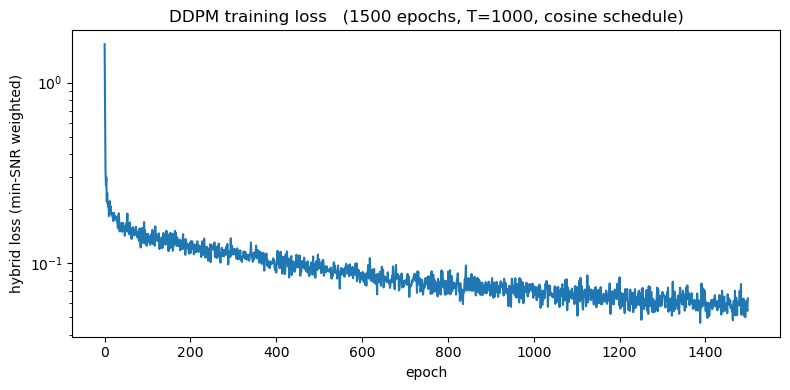

In [11]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(history["loss"])
ax.set_xlabel("epoch"); ax.set_ylabel("hybrid loss (min-SNR weighted)")
ax.set_title(f"DDPM training loss   ({EPOCHS} epochs, T={T_STEPS}, cosine schedule)")
ax.set_yscale("log")
plt.tight_layout(); plt.show()


## Sampling at different step counts — and why fewer steps looks worse here

The repo's `sample` runs the reverse process with an optional `step` parameter that visits every k-th timestep. **Important:** this is *naive* sub-sampling, not DDIM. The `backward_step` function uses **per-step** schedule constants (`betas[t]`, `posterior_variance[t]`) that were derived assuming we move from $t$ to $t-1$ — a one-timestep jump.

When `step=50`, we still call the per-step update, but we *actually* jump 50 timesteps between calls. The cumulative coefficients you'd need for a 50-step leap (e.g. $1 - \bar\alpha_{t-50}/\bar\alpha_t$ instead of $\beta_t$) are never computed. The trajectory drifts off the manifold the model was calibrated on.

**Consequence you'll see in the grid below: step=1 (full 1000 NN evals) looks visibly better than step=50, even though step=50 is ~50× faster.** That's not a coincidence — it's the cost of naive sub-sampling.

In production, no one uses this method for few-step sampling. Modern fast samplers are different objects:
- **DDIM** (Song et al. 2020, [arXiv 2010.02502](https://arxiv.org/abs/2010.02502)) — reformulates the reverse as a deterministic ODE whose integration is correct at any step count. Same trained model.
- **DPM-Solver / DPM-Solver++** (Lu et al. 2022) — higher-order ODE solvers. ~20 steps ≈ DDPM-1000 quality.
- **Distillation** (Consistency Models, SDXL Turbo, SDXL Lightning, FLUX-schnell) — train a separate model to do in 1–4 steps what DDPM-1000 does. Day 6.

The step-comparison below is therefore teaching the *motivation* for those methods, not their alternatives.

Same `EVAL_NOISE` starting point for every step count, so columns of the grids are comparable.


In [12]:
results = {}
step_configs = [1, 4, 10, 20, 50]   # 1=full 1000 steps, larger=fewer NN evals

for step in step_configs:
    n_eval = (T_STEPS + step - 1) // step
    # Warmup once
    _ = ddpm.sample_with_init(EVAL_NOISE[:1], step=step)
    torch.cuda.synchronize()
    t0 = time.time()
    samples = ddpm.sample_with_init(EVAL_NOISE, step=step)
    torch.cuda.synchronize()
    total_ms = (time.time() - t0) * 1000
    per_img_ms = total_ms / EVAL_NOISE.shape[0]
    results[step] = {
        "samples": samples,
        "n_eval": n_eval,
        "total_ms": total_ms,
        "per_img_ms": per_img_ms,
    }
    print(f"step={step:3d}  effective_nn_calls={n_eval:4d}  total={total_ms:8.1f} ms  per-img={per_img_ms:7.2f} ms")


step=  1  effective_nn_calls=1000  total= 11562.1 ms  per-img=1156.21 ms


step=  4  effective_nn_calls= 250  total=  2865.1 ms  per-img= 286.51 ms


step= 10  effective_nn_calls= 100  total=  1119.8 ms  per-img= 111.98 ms


step= 20  effective_nn_calls=  50  total=   559.4 ms  per-img=  55.94 ms


step= 50  effective_nn_calls=  20  total=   224.1 ms  per-img=  22.41 ms


## Side-by-side: same noise, different step counts

Row by row from top to bottom = more aggressive step-skipping (fewer NN evaluations, faster sampling, potentially worse quality).


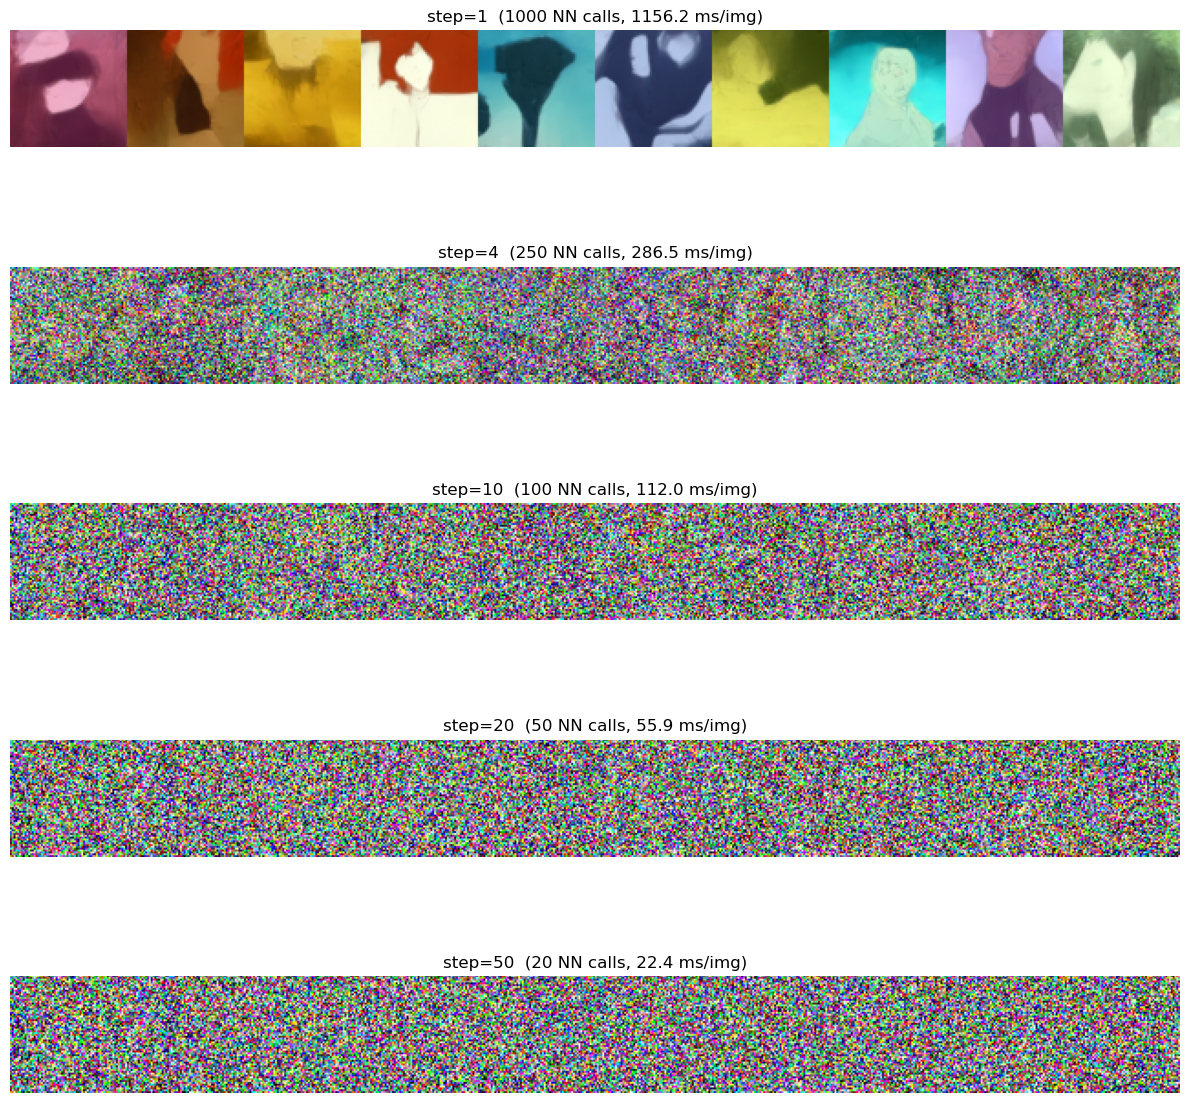

saved /mnt/local-fast/aalhejab/results/grids/day2_ddpm_yhl04.png  (10 imgs)


In [13]:
fig, axes = plt.subplots(len(step_configs), 1, figsize=(12, 2.5 * len(step_configs)))
for ax, step in zip(axes, step_configs):
    r = results[step]
    ax.imshow(to_uint8_grid(r["samples"], nrow=10))
    ax.axis("off")
    ax.set_title(f"step={step}  ({r['n_eval']} NN calls, {r['per_img_ms']:.1f} ms/img)")
plt.tight_layout(); plt.show()

# Save the full-step grid for the master table
save_grid(results[1]["samples"], ROOT / "results/grids/day2_ddpm_yhl04.png", nrow=5)


## Master-table entry

One row per sampler config. We measure latency precisely; quality is your visual rating (the `?/10` to fill in).


In [14]:
table_path = ROOT / "results" / "master_table.md"
if not table_path.exists():
    table_path.parent.mkdir(parents=True, exist_ok=True)
    table_path.write_text(
        "| Day | Model | Params(M) | Train(s) | VRAM(GB) | Steps | Step(ms) | Recon | FeatDiv | Quality |\n"
        "|---|---|---|---|---|---|---|---|---|---|\n"
    )

rows = []
for step in step_configs:
    r = results[step]
    rows.append(
        f"| 2 | DDPM YHL04 (step={step}) | {n_params/1e6:.2f} | {train_s:.1f} | {peak_vram:.2f} | "
        f"{r['n_eval']} | {r['per_img_ms']:.2f} | — | — | ?/10 |\n"
    )
with table_path.open("a") as f:
    for row in rows: f.write(row)

print(table_path.read_text())


| Day | Model | Params(M) | Train(s) | VRAM(GB) | Steps | Step(ms) | Recon | FeatDiv | Quality |
|---|---|---|---|---|---|---|---|---|---|
| 1 | baseline VAE          | 2.96          | 26.8      | 0.23     | 1 | 0.45      | 230        | —     | ?/10 |
| 1 | VAE v1 (bigger+anneal)| 11.82     | 25.7   | 0.43  | 1 | 0.44   | 204     | —     | ?/10 |
| 1 | VAE v2 (+perceptual)  | 11.82     | 40.0   | 0.89  | 1 | 0.44   | 75 | —     | ?/10 |
| 1 | baseline GAN (BCE)    | 1.91     | 44.0      | 0.57     | 1 | 0.39      | —     | 0.697 | ?/10 |
| 1 | GAN v1 (stability)    | 1.91 | 69.4  | 0.61 | 1 | 0.39  | —     | 0.657  | ?/10 |
| 1 | GAN v2 (hinge+R1+DiffAug)| 6.58| 86.8   | 0.82  | 1 | 0.40   | —     | 0.674   | ?/10 |
| 1 | baseline VAE          | 2.96          | 30.2      | 0.19     | 1 | 0.42      | 113        | —     | ?/10 |
| 1 | VAE v1 (bigger+anneal)| 11.82     | 29.2   | 0.40  | 1 | 0.43   | 94     | —     | ?/10 |
| 1 | VAE v2 (+perceptual)  | 11.82     | 43.0   | 0.85  | 1 | 0.

## Summary

What we used and where it comes from:

| Component | Source |
|---|---|
| `cosine_beta_schedule` | verbatim from `YHL04/ddpm/ddpm.py` |
| `UNet` (ε + v heads) | verbatim from `YHL04/ddpm/model/unet.py` |
| `normal_kl`, `discretized_gaussian_log_likelihood` | verbatim from `YHL04/ddpm/losses.py` (originally OpenAI's improved-diffusion) |
| `DDPM` class | adapted from `YHL04/ddpm/ddpm.py` — class arg `c` dropped because we use UNet (no conditioning) |
| Loss form | Improved DDPM hybrid (Nichol & Dhariwal 2021 §3.3) + min-SNR-γ weighting (Hang et al. 2023) |
| Sampling | full reverse with `x_recon.clamp_(-1, 1)` — the line that makes high-t numerically stable |

What's actually trained:
- ~10M-param UNet (ch=64, smaller than the repo's default 128)
- 200 anime images, batch 32, 2000 epochs (~13k gradient updates)
- Cosine schedule, T=1000
- AdamW lr=2e-4, gradient clipping at norm 1.0

What we measured:
- Loss curve
- Per-image latency at step counts {1, 4, 10, 20, 50}
- Visual sample quality (your call)

### Next steps

- **Classifier-free guidance** — train the UNet with random class dropout, then guide sampling. Day 3.
- **DDIM sampler** — Song et al. 2020. Deterministic sub-sampling with the same trained network.
- **Distillation** — train a smaller model to do in 1–4 steps what this one does in 1000. Day 6.
